In [1]:
#--------------------------------------------------------------------------------------
# SCRIPT TO TEST READING LEVELS AND VALUE PROFILES WITH ORIGINAL SIMULATED SCENARIOS
#--------------------------------------------------------------------------------------
import torch
import pandas as pd
import numpy as np
import glob
import os
import time
import random
import ollama
import transformers
import re
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from itertools import combinations
from pytorch_lightning import seed_everything
from scipy.stats import sem, t
from sentence_transformers import SentenceTransformer, util
seed_everything(42)

### CHECK GPU STATUS ###
def is_notebook():
    return True if 'JPY_PARENT_PID' in os.environ else False
USE_CUDA = torch.cuda.is_available()
device = torch.device("cuda" if USE_CUDA else "cpu")

### LOAD SCENARIOS ###
file_list = glob.glob(os.path.join(os.getcwd(), "Scenarios", "*.txt"))
scenarios = []     
for file_path in file_list:
    with open(file_path) as f_input:
        rows_all = f_input.readlines()[1:] # Remove line 1 - scenario number
        rows_all = ' '.join(rows_all)
        scenarios.append(rows_all)       
no_patients = len(scenarios)
print(f'*** Number of patients = {no_patients}')  
print(f'*** GPU is available: {USE_CUDA}')
print(f'*** Running off a Jupyter Notebook: {is_notebook()}')

/blue/prismap-ai-core/vnolan/conda/envs/APARI_Models/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-21 11:54:55.333375: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[rank: 0] Seed set to 42


*** Number of patients = 50
*** GPU is available: True
*** Running off a Jupyter Notebook: True


In [2]:
#--------------------------------------------------------------------------------------
# PROMPTS
#--------------------------------------------------------------------------------------
prompt_text = ''' 
Here is some information about a patient in hospital: {SCENARIO}. Using this information, your task is to generate a paragraph of text summarizing the values and preferences of this patient. You might include things about the importance of certain life aspects e.g. family, finances, travel and also their wishes regarding end-of-life care. 
It is acceptable to infer or generate new information. Please make each answer at least 10 sentences long. You should give your answer written in three different styles:
1) In the style of a 5th grade reading level. This is very easy to read and easily understood by an average 11-year-old student. This includes short sentences and words with fewer syllables.
2) In the style of an 8th or 9th grade reading level. This is plain English and easily understood by 13- to 15-year-old students. Sentences will be longer with more words with multiple syllables.
3) In the style of a college graduate. This is wery difficult to read and best understood by university graduates. This will be longer sentences with multi-syllabic words.
Give your answers formatted so that each paragraph starts and ends with ***. '''

prompt_text2 = ''' 
Here is some information about a patient in hospital: {SCENARIO}. Here is also some information about their values and wishes: {VALUES}.
Using this information, your task is to answer two questions:
1) What is the treatment being considered by the doctors for this patient? Provide the answer in no more than 5 words if possible.
2) Given the values of the patient, should the patient be treated using this treatment? '''


In [ ]:
#--------------------------------------------------------------------------------------
# GENERATING VALUE PROFILES AT DIFFERENT READING LEVELS FOR EACH SCENARIO
#--------------------------------------------------------------------------------------
all_data = []
for scenario_text in tqdm(scenarios):
    prompt1 = prompt_text.format(SCENARIO=scenario_text)
    response1 = ollama.chat(model='llama3', options={'temperature': 0.5}, messages=[{'role': 'system', 'content': prompt1}])
    sections = response1['message']['content'].split('***')
    sections = [section.strip() for section in sections if section.strip()]
    if len(sections) >= 6:
        data = {
            "Initial Text": scenario_text,
            "5th Grade Level": sections[1],
            "8th/9th Grade Level": sections[3],
            "College Graduate Level": sections[5]}
        all_data.append(data)
df = pd.DataFrame(all_data)
df.to_csv('GeneratedValueProfiles.csv', index=False)

#--------------------------------------------------------------------------------------
# PROMPTING FOR DECISION
#--------------------------------------------------------------------------------------
for scenario in range(no_patients):
    
    print(f'*---------------------------------{scenario}--------------------------------*')
    scenario_text = df.iloc[scenario, 0]
    value_1 = df.iloc[scenario, 1]
    value_2 = df.iloc[scenario, 2]
    value_3 = df.iloc[scenario, 3]
    
    prompt = prompt_text2.format(SCENARIO=scenario_text, VALUES=value_1)
    response1 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'system', 'content': prompt}])
    print('READING LEVEL 5:', response1['message']['content'])
    
    prompt = prompt_text2.format(SCENARIO=scenario_text, VALUES=value_2)
    response2 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'system', 'content': prompt}])
    print('READING LEVEL 8/9', response2['message']['content'])
    
    prompt = prompt_text2.format(SCENARIO=scenario_text, VALUES=value_3)
    response3 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'system', 'content': prompt}])
    print('READING LEVEL COLLEGE GRAD:', response3['message']['content'])   
    

In [3]:
#--------------------------------------------------------------------------------------
# MODEL SIMILARITY
#--------------------------------------------------------------------------------------
model = SentenceTransformer('all-MiniLM-L6-v2')
df = pd.read_csv('GeneratedValueProfiles_Simulations.csv', header = 0)

no_runs = 10
reading_level_sim1 = []
reading_level_sim2 = []
reading_level_sim3 = []

for scenario in range(no_patients)[0:34]:
    
    print(f'*---------------------------------{scenario}--------------------------------*')
    scenario_text = df.iloc[scenario, 0]
    value_1 = df.iloc[scenario, 1]
    value_2 = df.iloc[scenario, 2]
    value_3 = df.iloc[scenario, 3]
    
    reading1 = []
    reading2 = []
    reading3 = []
    
    for run in tqdm(range(no_runs)):       
        
        prompt = prompt_text2.format(SCENARIO=scenario_text, VALUES=value_1)
        response1 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'system', 'content': prompt}])
        match = re.search(r"2\.\s*(.*)", response1['message']['content'], re.DOTALL)
        answer_2 = match.group(1).strip() if match else None
        reading1.append(answer_2)

        prompt = prompt_text2.format(SCENARIO=scenario_text, VALUES=value_2)
        response2 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'system', 'content': prompt}])
        match = re.search(r"2\.\s*(.*)", response2['message']['content'], re.DOTALL)
        answer_2 = match.group(1).strip() if match else None
        reading2.append(answer_2)
    
        prompt = prompt_text2.format(SCENARIO=scenario_text, VALUES=value_3)
        response3 = ollama.chat(model='llama3', options={'temperature': 0.2}, messages=[{'role': 'system', 'content': prompt}])
        match = re.search(r"2\.\s*(.*)", response3['message']['content'], re.DOTALL)
        answer_2 = match.group(1).strip() if match else None
        reading3.append(answer_2)
    
    embeddings1 = model.encode(reading1, convert_to_tensor=True)
    embeddings2 = model.encode(reading2, convert_to_tensor=True)
    embeddings3 = model.encode(reading3, convert_to_tensor=True)

    similarity_matrix1 = util.cos_sim(embeddings1, embeddings1).cpu().numpy()
    similarity_df1 = pd.DataFrame(similarity_matrix1, columns=[f"String {i+1}" for i in range(len(reading1))], index=[f"String {i+1}" for i in range(len(reading1))])
    similarity_matrix2 = util.cos_sim(embeddings2, embeddings2).cpu().numpy()
    similarity_df2 = pd.DataFrame(similarity_matrix2, columns=[f"String {i+1}" for i in range(len(reading2))], index=[f"String {i+1}" for i in range(len(reading2))])
    similarity_matrix3 = util.cos_sim(embeddings3, embeddings3).cpu().numpy()    
    similarity_df3 = pd.DataFrame(similarity_matrix3, columns=[f"String {i+1}" for i in range(len(reading3))], index=[f"String {i+1}" for i in range(len(reading3))])
    
    main_diagonal_mask = ~np.eye(similarity_matrix1.shape[0], dtype=bool)
    off_diagonal_elements1 = similarity_matrix1[main_diagonal_mask]
    reading_level_sim1.append(off_diagonal_elements1)
    
    main_diagonal_mask = ~np.eye(similarity_matrix2.shape[0], dtype=bool)
    off_diagonal_elements2 = similarity_matrix2[main_diagonal_mask]
    reading_level_sim2.append(off_diagonal_elements2)

    main_diagonal_mask = ~np.eye(similarity_matrix3.shape[0], dtype=bool)
    off_diagonal_elements3 = similarity_matrix3[main_diagonal_mask]
    reading_level_sim3.append(off_diagonal_elements3)

F-statistic: 10.974492283326773
P-value: 1.7359179494237603e-05
There is a significant difference between the means of the reading levels.


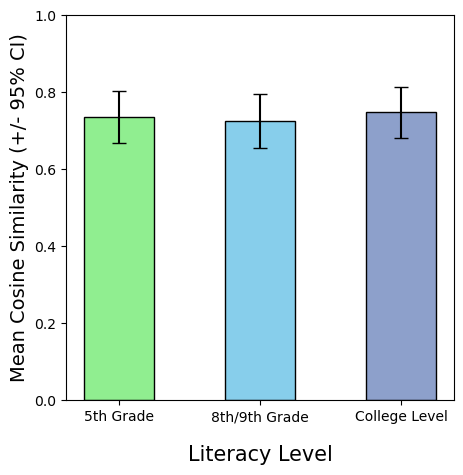

In [14]:
from scipy import stats
    
## ANOVA TEST OF MEANS BETWEEN READING LEVELS
data = [reading_level_sim1, reading_level_sim2, reading_level_sim3]
f_statistic, p_value = stats.f_oneway(np.array(reading_level_sim1).flatten(), np.array(reading_level_sim2).flatten(), np.array(reading_level_sim3).flatten())
print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")
if p_value < 0.05: print("There is a significant difference between the means of the reading levels.")
else: print("There is no significant difference between the means of the reading levels.")
means = [np.mean(d) for d in data]
std_devs = [np.std(d, ddof=1) for d in data] 
sample_sizes = [len(d) for d in data]
confidence_intervals = []
alpha = 0.05 
for i in range(len(data)):
    t_value = t.ppf(1 - alpha / 2, df=sample_sizes[i] - 1)  # t critical value
    margin_of_error = t_value * (std_devs[i] / np.sqrt(sample_sizes[i]))
    confidence_intervals.append(margin_of_error)

## PLOT OF SAMPLE CONSISTENCY OVER READING LEVELS

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar([0, 1, 2], means, yerr=confidence_intervals, capsize=5, color=['lightgreen', 'skyblue', '#8da0cb'], edgecolor='black', width =0.5)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['5th Grade', '8th/9th Grade', 'College Level'])
ax.set_ylabel('Mean Cosine Similarity (+/- 95% CI)', fontsize=14)
ax.set_xlabel('Literacy Level', size = 15, labelpad=15)
ax.set_ylim(0.0, 1.0)
plt.show()
#print(means, confidence_intervals)